# 03 Exploratory Data Analysis - Univariate and Bivariate Analysis

### Problem Statement: 
- What factors drive the commercial success of a game, and how can we predict it?

This notebook focuses on Variate Analysis. We analyze individual variables to see their reach (Univariate) and relationships between variables to see what drives popularity (Bivariate).

What factors actually drive the commercial success of a game, and how can developers or publishers predict whether a game will succeed or fail before investing heavily in it?”


1. Setup

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('../data/processed/cleaned_game_data.csv')
df['release'] = pd.to_datetime(df['release'])

print(f'Dataset loaded with {len(df):,} entries.')

Dataset loaded with 66,427 entries.


# 2. Univariate Analysis (Individual Success Factors)

We analyze variables one by one to see their distribution and Success Floor.

A. Metric: All-Time Peak Players

This is our primary indicator of how many people actually play a game at once.

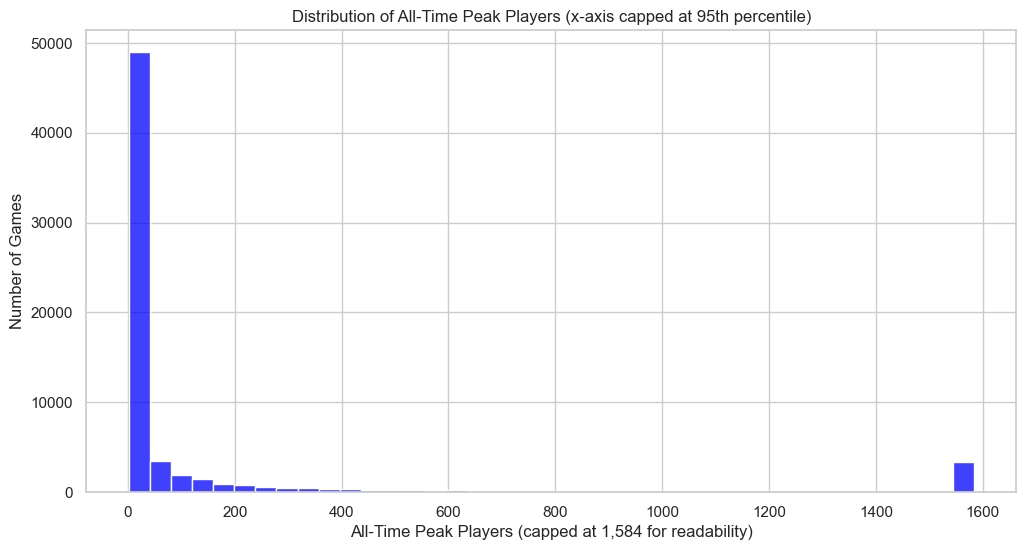

In [14]:
peak_cap = df['all_time_peak'].quantile(0.95)
peak_plot = df[df['all_time_peak'] > 0].copy()
peak_plot['all_time_peak_capped'] = peak_plot['all_time_peak'].clip(upper=peak_cap)

sns.histplot(data=peak_plot, x='all_time_peak_capped', bins=40, color='blue')
plt.title('Distribution of All-Time Peak Players (x-axis capped at 95th percentile)')
plt.xlabel('All-Time Peak Players (capped at 1,584 for readability)')
plt.ylabel('Number of Games')
plt.show()


Insight:

This histogram is designed to show the typical market outcome, not just the rare blockbuster cases. To keep the chart readable without using log scaling, the x-axis is capped at the 95th percentile. Even with that cap, the distribution is heavily concentrated near the low end, which shows that most games attract only a small live player base.

What the chart is telling us:
- The median all-time peak is only 7 players.
- 75% of games stay below 47 players.
- Only a small minority push into the hundreds or thousands.

Why this chart fits the insight:
A capped histogram is easier for most readers to understand than a log-scaled chart, and it keeps the focus on where the majority of games actually sit.


B. Metric: Total Reviews

This shows the Engagement and historical reach of a game.

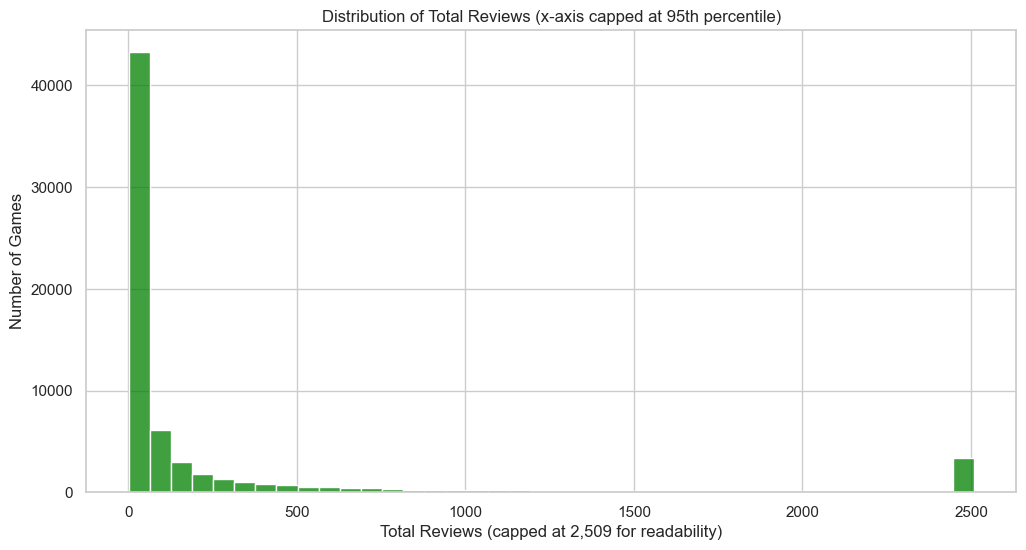

In [15]:
review_cap = df['total_reviews'].quantile(0.95)
review_plot = df[df['total_reviews'] > 0].copy()
review_plot['total_reviews_capped'] = review_plot['total_reviews'].clip(upper=review_cap)

sns.histplot(data=review_plot, x='total_reviews_capped', bins=40, color='green')
plt.title('Distribution of Total Reviews (x-axis capped at 95th percentile)')
plt.xlabel('Total Reviews (capped at 2,509 for readability)')
plt.ylabel('Number of Games')
plt.show()


Insight:

This review histogram also uses a capped x-axis instead of log scaling so that the main body of the market is easy to read. It shows that most games collect only a small number of reviews, which supports the idea that early community traction is rare and uneven.

What the chart is telling us:
- The median game has only 26 total reviews.
- 75% of games stay below 134 reviews.
- A small number of titles collect very large review volumes, but they are exceptions.

Why this chart fits the insight:
Reviews act as visible social proof on Steam. Showing their distribution clearly helps explain why so many games remain niche even if a few titles break far ahead of the pack.


# 3. Bivariate Analysis (Relationship to Success)

We now compare two variables to see what actually triggers a success breakout.

A. Genre vs Success (Peak Players)

Which genre gives you the best chance to be a Hit?

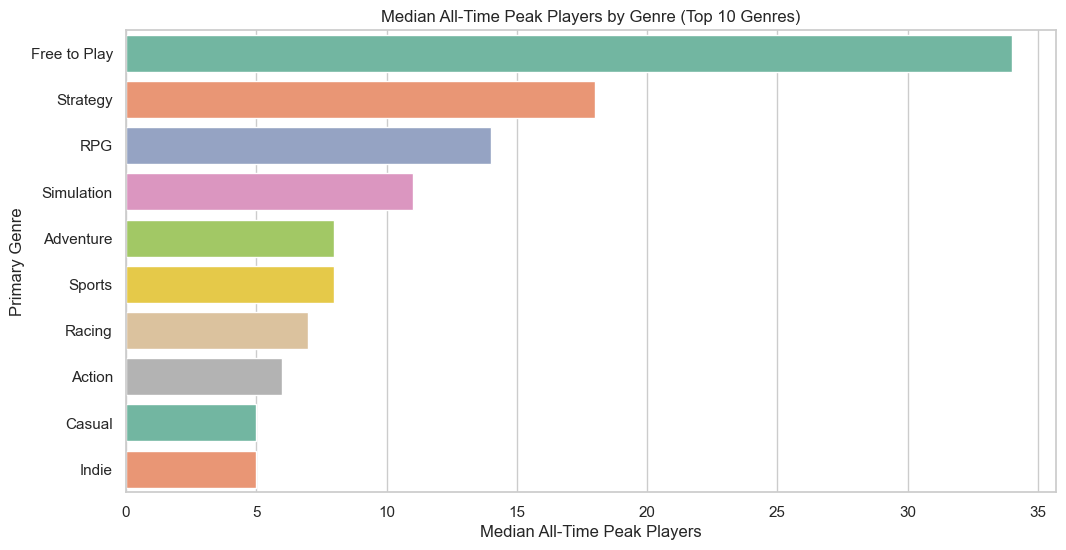

In [16]:
top_genres = df['primary_genre'].value_counts().head(10).index
genre_summary = (
    df[df['primary_genre'].isin(top_genres)]
    .groupby('primary_genre')['all_time_peak']
    .agg(median='median', p90=lambda s: s.quantile(0.90))
    .reset_index()
    .sort_values('median', ascending=False)
)

plt.figure(figsize=(12, 7))
sns.barplot(data=genre_summary, x='median', y='primary_genre', color='skyblue')
sns.scatterplot(data=genre_summary, x='p90', y='primary_genre', color='darkblue', s=100, label='90th percentile')
plt.title('Genre Success Floor vs Breakout Potential (Top 10 Genres)')
plt.xlabel('All-Time Peak Players')
plt.ylabel('Primary Genre')
plt.legend(title='Marker')
plt.show()


Insight:

This chart now measures median all-time peak by genre, which matches the idea of a success floor much better than the earlier outlier-heavy boxplot. Since the claim is about which genres are safer bets on average, median performance is the right metric to show.

What the chart is telling us:
- Strategy and RPG have stronger typical performance than Action, Casual, or Indie.
- Action can still produce very large hits, but its average game is not as safe as the median-outcome genres.
- Free to Play shows the highest median in this top-10 view, but it is also a structurally different market model and should be interpreted separately.

Why this chart fits the insight:
A median bar chart is simple to read and directly answers the question: which genres give a developer a better typical chance of attracting players?


B. Quality (Rating) vs Success (Peak Players)

Does a good game always equal a successful game?

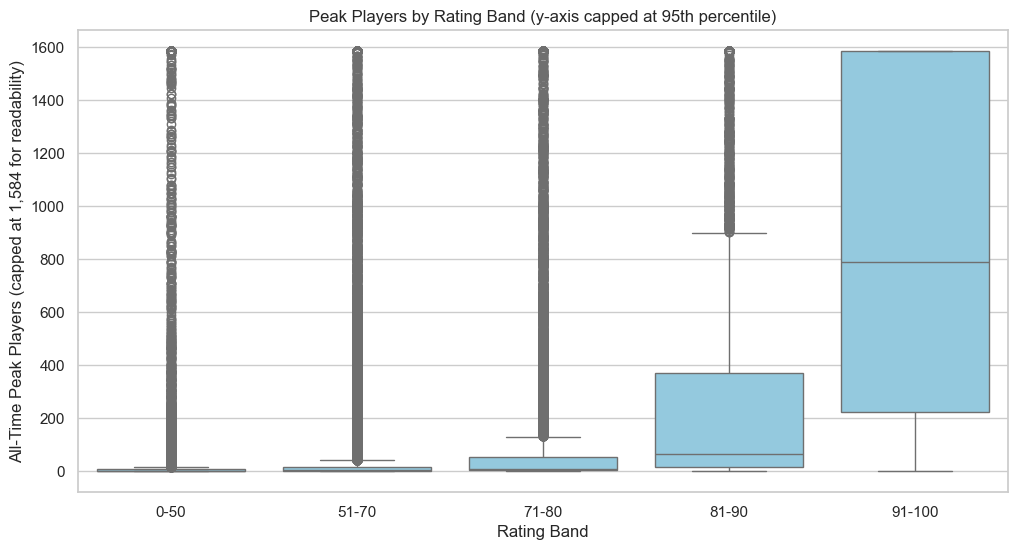

In [17]:
rating_plot = df[(df['rating'] > 0) & (df['all_time_peak'] > 0)].copy()
rating_plot['rating_band'] = pd.cut(
    rating_plot['rating'],
    bins=[0, 50, 70, 80, 90, 100],
    labels=['0-50', '51-70', '71-80', '81-90', '91-100'],
    include_lowest=True
)
peak_cap = rating_plot['all_time_peak'].quantile(0.95)
rating_plot['all_time_peak_capped'] = rating_plot['all_time_peak'].clip(upper=peak_cap)

sns.boxplot(data=rating_plot, x='rating_band', y='all_time_peak_capped', color='skyblue')
plt.title('Peak Players by Rating Band (y-axis capped at 95th percentile)')
plt.xlabel('Rating Band')
plt.ylabel('All-Time Peak Players (capped at 1,584 for readability)')
plt.show()


Insight:

The earlier scatterplot was difficult to read because too many points overlapped, and the log-scaled y-axis made the message less intuitive. This boxplot groups games into rating bands and compares their player ranges directly, with the y-axis capped at the 95th percentile for readability.

What the chart is telling us:
- Higher-rated games usually have a better median outcome.
- But the spread inside each rating band is still wide, so rating alone does not guarantee success.
- In other words, quality helps, but it does not fully explain discovery and reach.

Why this chart fits the insight:
This visualization is easier for non-technical readers because it shows both the typical result and the variation inside each rating band without relying on log scaling.


C. Release Year vs Success

Is it getting harder to succeed on Steam?

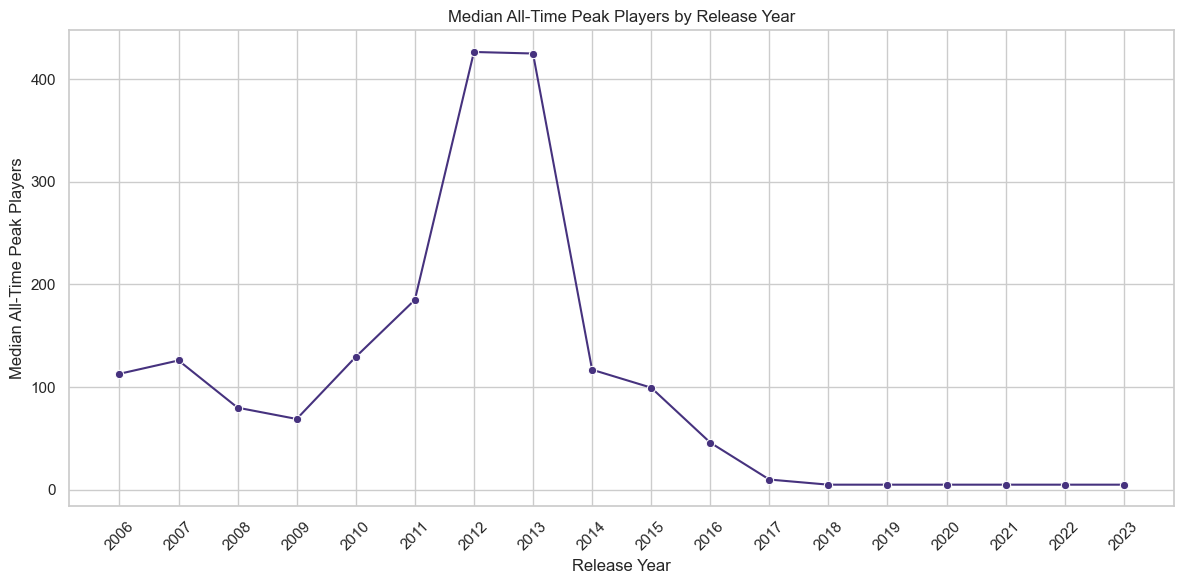

In [18]:
year_success = (
    df.dropna(subset=['release'])
    .groupby(df['release'].dt.year)['all_time_peak']
    .median()
)

sns.lineplot(x=year_success.index, y=year_success.values, marker='o')
plt.title('Median All-Time Peak Players by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Median All-Time Peak Players')
plt.xticks(year_success.index, rotation=45)
plt.tight_layout()
plt.show()


Insight:

This time-series line chart already matches the question well, so the main improvement is clearer axis labeling. It tracks median all-time peak by release year, which keeps the focus on the typical game released in each year instead of letting a few extreme hits dominate the story.

What the chart is telling us:
- Median success was much higher in the early 2010s.
- From 2017 onward, the typical game falls to very low peak-player levels.
- This supports the idea that the market has become much more crowded and competitive over time.

Important caution:
Recent years should still be interpreted carefully because newer releases have had less time to mature, but the broader downward pattern is still clear.


4. Summary
- Univariate: Showed us that the majority of games are small (niche).
- Bivariate: Showed us that Genre choice influences the probability of success, but Rating alone does not. 

Next, we move to 04_statistical_analysis.ipynb to mathematically verify these relationships.